d:\COLLEGE\DAIICT\Semester-2\Applied Forecasting\project\sahil\Nifty50-Forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\COLLEGE\DAIICT\Semester-2\Applied Forecasting\project\sahil\Nifty50-Forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\COLLEGE\DAIICT\Semester-2\Applied Forecasting\project\sahil\Nifty50-Forecasting\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
d:\COLLEGE\DAIICT\Semester-2\Applied Forecasting\project\sahil\Nifty50-Foreca


📊 MODEL PERFORMANCE REPORT
TRAIN RMSE: 0.0122
TEST  RMSE: 0.0104
------------------------------
TRAIN MAE:  0.0082
TEST  MAE:  0.0078
TRAIN MSE:  0.0001
TEST  MSE:  0.0001
✅ Model is generalizing well. Error difference is -14.47%.


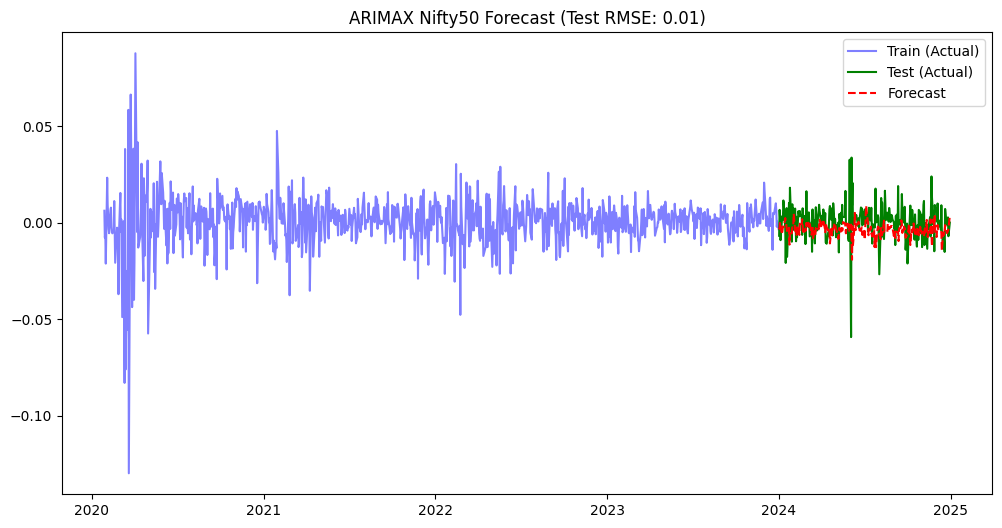

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error

# -------------------------------
# STEP 0: Load Data
# -------------------------------
# (Assuming CSV is loaded as per your script)
df = pd.read_csv("D:\\COLLEGE\\DAIICT\\Semester-2\\Applied Forecasting\\project\\sahil\\Nifty50-Forecasting\\ARIMAX\\nifty_features.csv")
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
df = df.sort_index()

y = df['target']
X = df.drop(columns=['target'])

# -------------------------------
# STEP 1 & 2: Stationarity & Differencing
# -------------------------------
def check_stationarity(series):
    result = adfuller(series)
    return result[1] <= 0.05

d = 0
if not check_stationarity(y):
    y = y.diff().dropna()
    X = X.iloc[1:] # Align X with y after dropping NaN
    d = 1
    print("✅ Applied differencing (d=1) to make the series stationary.")

# -------------------------------
# STEP 3: Train-Test Split
# -------------------------------
train_size = int(len(y) * 0.8)
y_train, y_test = y[:train_size], y[train_size:]
X_train, X_test = X[:train_size], X[train_size:]

# -------------------------------
# STEP 4: Train ARIMAX Model
# -------------------------------
model = SARIMAX(y_train,
                exog=X_train,
                order=(1, 0, 1), # d is 0 here because we manually differenced y
                enforce_stationarity=False,
                enforce_invertibility=False)

model_fit = model.fit(disp=False)

# -------------------------------
# STEP 5: Prediction (Training & Testing)
# -------------------------------
# Predicting on Train set to check for overfitting
y_train_pred = model_fit.predict(start=0, end=len(y_train)-1, exog=X_train)

# Predicting on Test set
y_test_pred = model_fit.predict(start=len(y_train), 
                                end=len(y_train) + len(y_test) - 1, 
                                exog=X_test)

# -------------------------------
# STEP 6: Evaluation & Overfitting Check
# -------------------------------
# Training Metrics
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)

# Testing Metrics
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)

test_mse = mean_squared_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print("\n" + "="*30)
print("📊 MODEL PERFORMANCE REPORT")
print("="*30)
print(f"TRAIN RMSE: {train_rmse:.4f}")
print(f"TEST  RMSE: {test_rmse:.4f}")
print("-" * 30)
print(f"TRAIN MAE:  {train_mae:.4f}")
print(f"TEST  MAE:  {test_mae:.4f}")
print(f"TRAIN MSE:  {train_rmse**2:.4f}")
print(f"TEST  MSE:  {test_mse:.4f}")

print("="*30)

# Logic to detect overfitting
rmse_diff = (test_rmse - train_rmse) / train_rmse * 100
if rmse_diff > 20:
    print(f"⚠️ WARNING: Potential Overfitting! Test error is {rmse_diff:.2f}% higher than Train error.")
else:
    print(f"✅ Model is generalizing well. Error difference is {rmse_diff:.2f}%.")

# -------------------------------
# STEP 7: Plot Results
# -------------------------------
plt.figure(figsize=(12,6))
plt.plot(y_train.index, y_train, label='Train (Actual)', color='blue', alpha=0.5)
plt.plot(y_test.index, y_test, label='Test (Actual)', color='green')
plt.plot(y_test.index, y_test_pred, label='Forecast', color='red', linestyle='--')
plt.title(f"ARIMAX Nifty50 Forecast (Test RMSE: {test_rmse:.2f})")
plt.legend()
plt.show()